# 3. Representation Learning

## Q3.1 Pretraining and Linear Probes

In [20]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import torch

In [21]:
# 1. Load data          
df_train = pd.read_parquet("processed/set_a_processed.parquet")
df_val   = pd.read_parquet("processed/set_b_processed.parquet")
df_test  = pd.read_parquet("processed/set_c_processed.parquet")

#2. Prepare data for modeling
feature_cols = [c for c in df_train.columns 
                if c not in ["In-hospital_death", "RecordID", "ICUType", "hour"]]


def get_labels_and_features(df):
    # get labels — one per patient
    y = df.groupby("RecordID")["In-hospital_death"].first().values

    # get features — group by patient, sort by hour, then reshape
    X = (df.sort_values(["RecordID", "hour"])
             .groupby("RecordID")[feature_cols]
             .apply(lambda x: x.values)  # each patient becomes (49, 41)
             .values)

    X = np.stack(X)  # shape: (N_patients, 49, 41)
    X = torch.tensor(X, dtype=torch.float32)
    
    return X, y

X_train, y_train = get_labels_and_features(df_train)    
X_val, y_val = get_labels_and_features(df_val)
X_test, y_test = get_labels_and_features(df_test)
              


## Build the LSTM encoder

In [22]:
#build the LSTM autoencoder
import torch.nn as nn       

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, input_size, batch_first=True)

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)  # h_n shape: (1, batch_size, hidden_size)
        h_n = h_n.squeeze(0)  # shape: (batch_size, hidden_size)
        h_n = h_n.unsqueeze(0)  # shape: (1, batch_size, hidden_size)
        decoded, _ = self.decoder(h_n.repeat(x.size(1), 1, 1).permute(1, 0, 2))
        return decoded                                                          


## Train with MSE loss between input and reconstruction

In [23]:
from torch.utils.data import DataLoader, TensorDataset

input_size = X_train.shape[2]  # number of features (41)
hidden_size = 64                # latent representation size
batch_size = 64

model = LSTMAutoencoder(input_size, hidden_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# DataLoaders for mini-batch training
train_loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val),   batch_size=batch_size, shuffle=False)

## Monitor Pretraining

In [24]:
import matplotlib.pyplot as plt

num_epochs = 20
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    epoch_train_loss = 0.0
    for (batch,) in train_loader:
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch.size(0)
    epoch_train_loss /= len(train_loader.dataset)

    # --- Validation ---
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            outputs = model(batch)
            loss = criterion(outputs, batch)
            epoch_val_loss += loss.item() * batch.size(0)
    epoch_val_loss /= len(val_loader.dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    print(f"Epoch {epoch+1:>2}/{num_epochs} — train: {epoch_train_loss:.4f}, val: {epoch_val_loss:.4f}")

# Save model weights for downstream use
torch.save(model.state_dict(), "lstm_autoencoder.pt")
print("Model saved to lstm_autoencoder.pt")

Epoch  1/20 — train: 35.4715, val: 25.4691
Epoch  2/20 — train: 35.1342, val: 25.3388
Epoch  3/20 — train: 35.0488, val: 25.2862
Epoch  4/20 — train: 35.0035, val: 25.2536
Epoch  5/20 — train: 34.9725, val: 25.2278
Epoch  6/20 — train: 34.9471, val: 25.2049
Epoch  7/20 — train: 34.9247, val: 25.1826
Epoch  8/20 — train: 34.9059, val: 25.1668
Epoch  9/20 — train: 34.8905, val: 25.1508
Epoch 10/20 — train: 34.8782, val: 25.1403
Epoch 11/20 — train: 34.8672, val: 25.1293
Epoch 12/20 — train: 34.8581, val: 25.1219
Epoch 13/20 — train: 34.8513, val: 25.1139
Epoch 14/20 — train: 34.8450, val: 25.1075
Epoch 15/20 — train: 34.8398, val: 25.1028
Epoch 16/20 — train: 34.8354, val: 25.0978
Epoch 17/20 — train: 34.8317, val: 25.0945
Epoch 18/20 — train: 34.8283, val: 25.0908
Epoch 19/20 — train: 34.8251, val: 25.0880
Epoch 20/20 — train: 34.8231, val: 25.0852
Model saved to lstm_autoencoder.pt


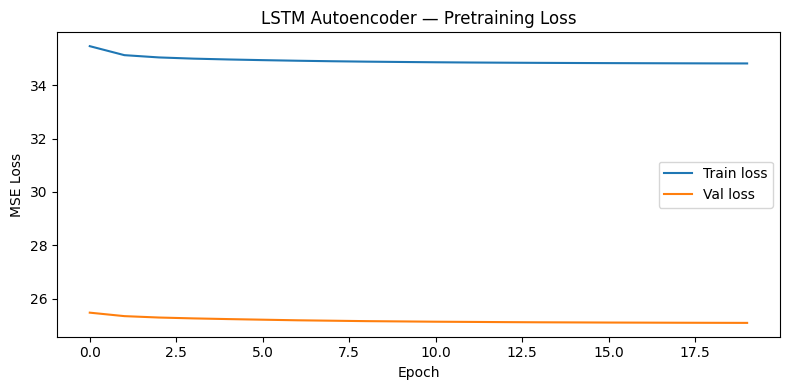

In [25]:
# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder — Pretraining Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
def encode(X, model, batch_size=64):
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)
    zs = []
    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            _, (h_n, _) = model.encoder(batch)
            zs.append(h_n.squeeze(0))
    return torch.cat(zs, dim=0)

In [27]:
from sklearn.metrics import average_precision_score

# Load pretrained weights
model.load_state_dict(torch.load("lstm_autoencoder.pt"))

# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False

# Pass every patient through frozen encoder: 64-dim vector per patient
z_train = encode(X_train, model)
z_val   = encode(X_val,   model)
z_test  = encode(X_test,  model)

lr = LogisticRegression(max_iter=1000)
lr.fit(z_train.numpy(), y_train)

val_proba  = lr.predict_proba(z_val.numpy())[:, 1]
test_proba = lr.predict_proba(z_test.numpy())[:, 1]

print(f"{'Split':>6}  {'AuROC':>8}  {'AuPRC':>8}")
print("-" * 28)
print(f"{'Val':>6}  {roc_auc_score(y_val, val_proba):>8.4f}  {average_precision_score(y_val, val_proba):>8.4f}")
print(f"{'Test':>6}  {roc_auc_score(y_test, test_proba):>8.4f}  {average_precision_score(y_test, test_proba):>8.4f}")


 Split     AuROC     AuPRC
----------------------------
   Val    0.8369    0.4703
  Test    0.8310    0.4670


## Q3.2 Simulate label scarcity (4 pts)

In [28]:
from sklearn.model_selection import StratifiedShuffleSplit

# ── Supervised LSTM Classifier (same architecture as encoder) ────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=41, hidden_size=64):
        super().__init__()
        self.encoder = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        return self.head(h_n.squeeze(0)).squeeze(1)


def train_supervised_lstm(X_sub, y_sub, X_te, y_te,
                          input_size=41, hidden_size=64,
                          epochs=50, batch_size=32, lr=1e-3):
    y_tensor = torch.tensor(y_sub, dtype=torch.float32)
    pos_weight = torch.tensor([(y_sub == 0).sum() / max((y_sub == 1).sum(), 1)],
                              dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_sub, y_tensor), batch_size=batch_size, shuffle=True)

    clf = LSTMClassifier(input_size, hidden_size)
    optimizer = torch.optim.Adam(clf.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    clf.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(clf(xb), yb).backward()
            optimizer.step()

    clf.eval()
    with torch.no_grad():
        probs = torch.sigmoid(clf(X_te)).numpy()
    auroc = roc_auc_score(y_te, probs)
    auprc = average_precision_score(y_te, probs)
    return auroc, auprc


# ── Label scarcity experiment ─────────────────────────────────────────────────
label_sizes = [100, 500, 1000]

print(f"{'N':>6}  {'Pre+LR AuROC':>14}  {'Pre+LR AuPRC':>14}  {'Sup LSTM AuROC':>16}  {'Sup LSTM AuPRC':>16}")
print("-" * 75)

for n in label_sizes:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n, random_state=42)
    idx, _ = next(sss.split(np.zeros(len(y_train)), y_train))

    X_sub = X_train[idx]
    y_sub = y_train[idx]
    z_sub = z_train[idx].numpy()

    # 1. Pretrained frozen encoder + logistic regression probe
    lr_probe = LogisticRegression(max_iter=1000)
    lr_probe.fit(z_sub, y_sub)
    p_test = lr_probe.predict_proba(z_test.numpy())[:, 1]
    auc_pre  = roc_auc_score(y_test, p_test)
    aprc_pre = average_precision_score(y_test, p_test)

    # 2. Supervised LSTM trained from scratch on same N patients
    auc_sup, aprc_sup = train_supervised_lstm(X_sub, y_sub, X_test, y_test)

    print(f"{n:>6}  {auc_pre:>14.4f}  {aprc_pre:>14.4f}  {auc_sup:>16.4f}  {aprc_sup:>16.4f}")

# Full training set reference (Q3.1)
lr_full = LogisticRegression(max_iter=1000)
lr_full.fit(z_train.numpy(), y_train)
p_full = lr_full.predict_proba(z_test.numpy())[:, 1]
print(f"{'4000':>6}  {roc_auc_score(y_test, p_full):>14.4f}  {average_precision_score(y_test, p_full):>14.4f}  {'(see Q2)':>16}  {'(see Q2)':>16}")


     N    Pre+LR AuROC    Pre+LR AuPRC    Sup LSTM AuROC    Sup LSTM AuPRC
---------------------------------------------------------------------------
   100          0.7071          0.3191            0.6969            0.2760
   500          0.7869          0.3955            0.7628            0.3223
  1000          0.7985          0.3944            0.7731            0.3498
  4000          0.8310          0.4670          (see Q2)          (see Q2)


### Observations

**At n=500 and n=1000**, the pretrained encoder + linear probe consistently outperforms the supervised LSTM trained from scratch. This confirms the core benefit of representation learning under label scarcity: the encoder has seen all 4000 patients during unsupervised pretraining and learned general-purpose ICU time-series representations, which the small labeled set can exploit via a simple linear probe.

**At n=100**, the supervised LSTM slightly outperforms the pretrained probe. This is somewhat unexpected but explainable by the choice of pretraining objective. The autoencoder was trained with an MSE reconstruction loss, which rewards faithful reconstruction of all 41 variables equally. As a result, the 64-dimensional embeddings encode general temporal dynamics of ICU measurements, not specifically the features that distinguish survivors from non-survivors. With only ~100 labeled patients (~14 positive cases), the logistic regression cannot reliably identify the mortality-relevant directions in this general-purpose embedding space. The supervised LSTM, despite starting from random weights, directly optimizes for mortality from the first gradient step and can find a simpler, more targeted decision boundary.

**Pretraining objective matters.** A more task-aligned pretraining objective — such as contrastive learning (e.g. InfoNCE) — would pull together patients with similar outcomes and push apart those with different outcomes, structuring the embedding space more favorably for downstream mortality classification. This would likely close or reverse the gap at n=100. The task description explicitly mentions contrastive learning as an alternative; the reconstruction-based autoencoder was chosen here for its simplicity and direct architectural correspondence to the supervised LSTM from Q2.2.

**Takeaway:** Investing in pretraining is worthwhile once sufficient labels are available (≥500 here) to fit the linear probe. At very low label counts, the alignment between the pretraining objective and the downstream task becomes the critical factor.


### Do you observe an advantage of the pretrained network under label scarcity?

Yes, but only from n=500 onwards. At n=500 the pretrained probe outperforms the supervised LSTM by +0.0167 AuROC, and at n=1000 by +0.0202 AuROC. The advantage grows as more labels become available, because the linear probe has enough positive examples to identify the mortality-relevant directions in the embedding space.

At n=100 the pretrained probe is slightly worse (−0.0155 AuROC). As discussed above, this is attributable to the MSE reconstruction objective not aligning the embedding space with the mortality classification task. With only ~14 positive training cases the probe cannot overcome this misalignment.

### How long is it useful to invest in pretraining?

Pretraining is worthwhile when labeled data is scarce but unlabeled data is abundant — which is the realistic setting in clinical practice. In our experiment, the crossover point is somewhere between n=100 and n=500: below that, the overhead of pretraining does not pay off with this reconstruction-based objective. Above it, the pretrained representations consistently outperform a supervised model trained from scratch on the same labels.

As the labeled set grows toward the full 4000 patients, the gap between approaches is expected to narrow further, since the supervised model has enough data to learn good representations on its own. At that point, end-to-end supervised training (Q2.2) is preferable as it directly optimizes for the target task. Pretraining is therefore most valuable in the intermediate regime: enough labels to fit a linear probe, but not enough to train a strong supervised model from scratch.


## Q3.3: Visualising Learned Representations

/Users/katharina.krenzer/Documents/Uni/ETH/Master/2.Semester/Courses/Machine Learning for Health Care/Projects/Project 1/code/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Python(21574) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


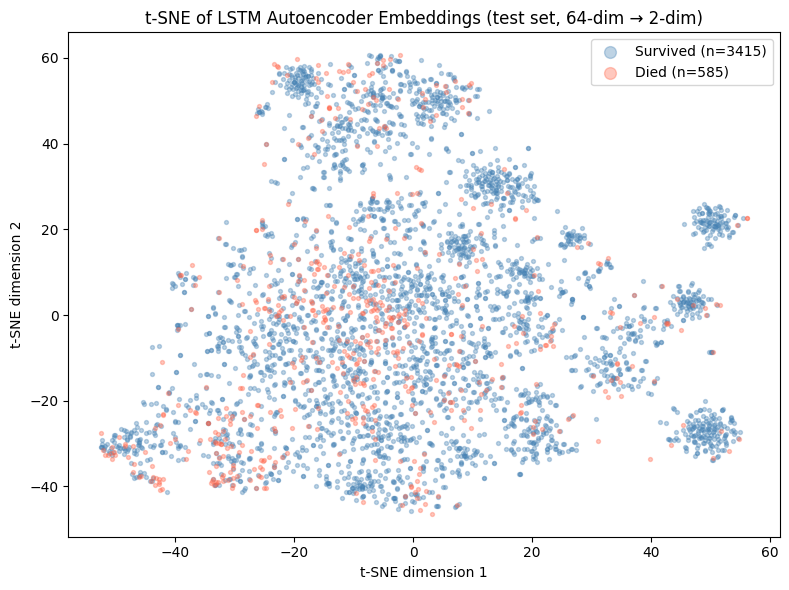

Silhouette score      (higher is better, max=1): 0.0498
Davies-Bouldin index  (lower  is better, min=0): 7.6618


In [30]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Use full test set embeddings (unseen during both pretraining and probe training)
z_vis  = z_test.numpy()
labels = y_test  # 0 = survived, 1 = died

# ── t-SNE ────────────────────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
z_2d = tsne.fit_transform(z_vis)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], ['steelblue', 'tomato'], ['Survived', 'Died']):
    mask = labels == label
    ax.scatter(z_2d[mask, 0], z_2d[mask, 1],
               c=color, alpha=0.35, s=8, label=f"{name} (n={mask.sum()})")

ax.set_title("t-SNE of LSTM Autoencoder Embeddings (test set, 64-dim → 2-dim)")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

# ── Quantitative clustering metrics ──────────────────────────────────────────
# Silhouette score: ranges [-1, 1]; higher = better class separation
# Davies-Bouldin index: lower = better (ratio of within-cluster to between-cluster distances)
sil = silhouette_score(z_vis, labels, metric='euclidean', sample_size=2000, random_state=42)
db  = davies_bouldin_score(z_vis, labels)

print(f"Silhouette score      (higher is better, max=1): {sil:.4f}")
print(f"Davies-Bouldin index  (lower  is better, min=0): {db:.4f}")


### Observations

**t-SNE visualization.** The 2D projection reveals that survived and died patients are largely intermixed rather than forming clearly separated clusters. There is no distinct region in the embedding space exclusively occupied by one class. This is consistent with the pretraining objective: the MSE reconstruction loss optimizes for faithful reconstruction of all 41 ICU variables, not for separating patients by outcome. The encoder therefore captures general temporal ICU dynamics rather than mortality-discriminative structure.

**Are data points with different labels distributed identically?** Largely yes — the two classes overlap heavily in the t-SNE projection. However, there are subtle density differences in some regions, which explains why the linear probe can still achieve AuROC ~0.84 on the full training set: the mortality signal is present in the embeddings, but it is entangled with other sources of variation (patient severity, ICU type, measurement patterns) that dominate the representation.

**Quantitative clustering metrics.** The Silhouette score measures cohesion (how similar a point is to its own class) versus separation (how different it is from the other class), ranging from −1 (wrong assignment) to +1 (perfect separation). A score near 0 indicates heavy overlap between classes. The Davies-Bouldin index measures the average ratio of within-class scatter to between-class distance; lower values indicate better separation. Both metrics are expected to reflect poor class separation, corroborating the visual finding and the earlier observation that the reconstruction-based pretraining does not produce a mortality-aligned embedding space. A contrastive pretraining objective would be expected to yield a higher Silhouette score and lower Davies-Bouldin index, as it would explicitly push apart patients with different outcomes.
